# Apache Parquet

### An introduction to efficient columnar storage


## What is Apache Parquet?

- Apache Parquet is a **binary, column-oriented data file format**.
- It is designed for efficient storage and retrieval, reducing both CPU and I/O work.
- Its layout includes **row groups, column chunks, and pages**.
- It supports page compression and column encodings such as dictionary encoding.
- Statistics and indexes help readers skip irrelevant data.
- It is widely supported by Hadoop, Spark, pandas, and cloud data platforms.


## Row-oriented vs. column-oriented storage

Columnar storage keeps values from the same column together. Analytical queries can therefore read only the required columns, improving cache use and reducing I/O.

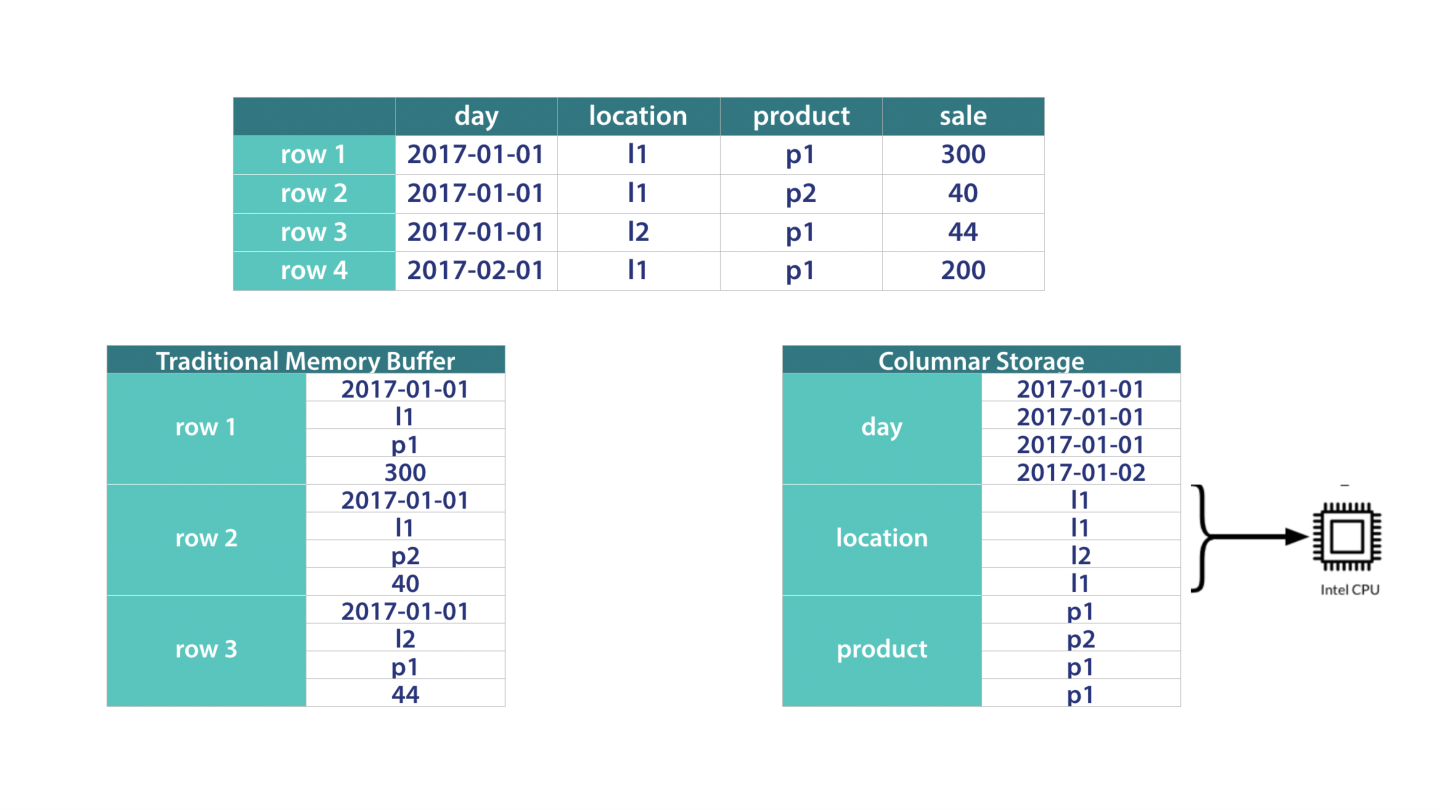


## Columnar layout and encoding

Values are grouped by column and can be encoded in chunks. Common techniques include dictionary, run-length, delta, and prefix encoding.

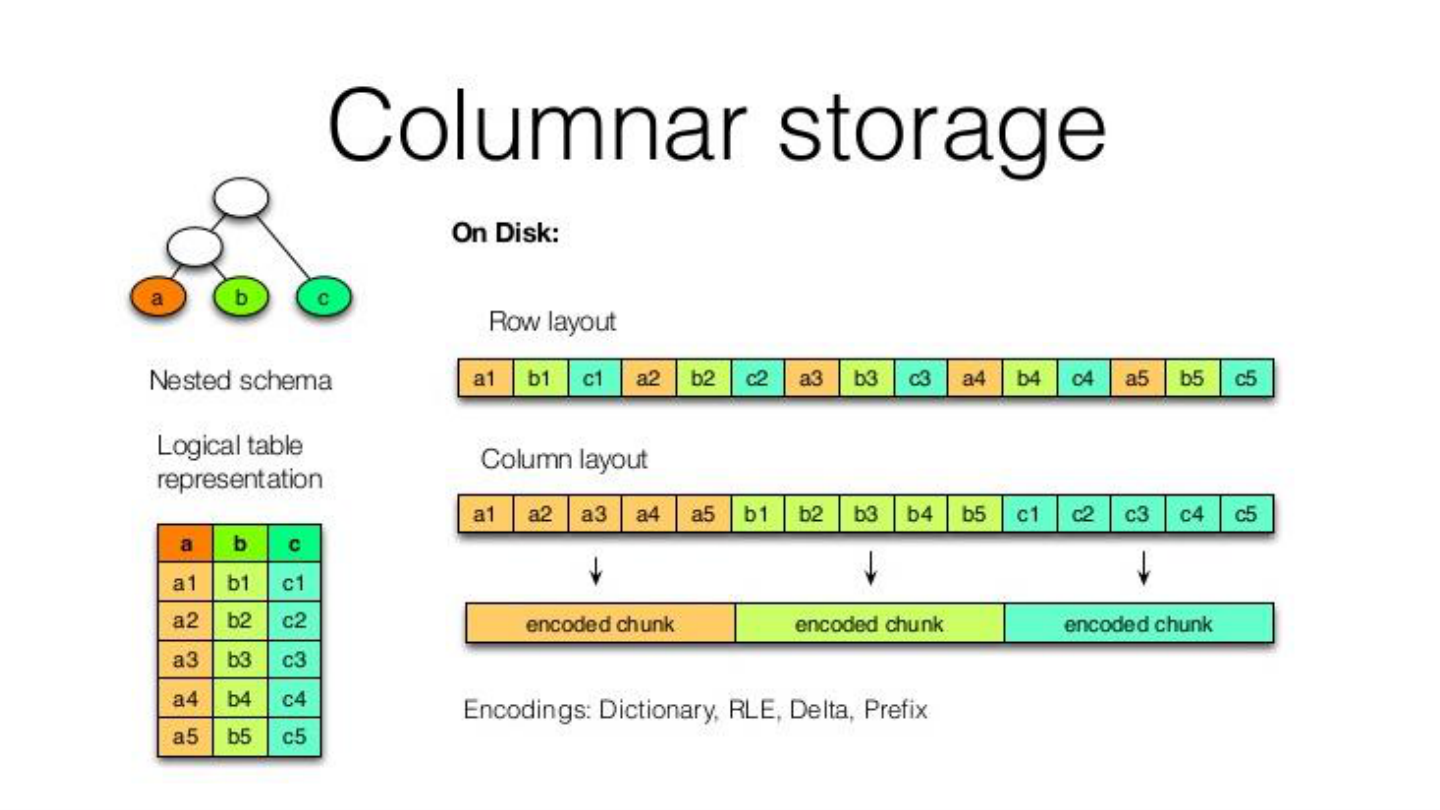


## Key concepts

- **Block size:** The storage system's physical allocation unit, such as an HDFS block.
- **Row group:** A horizontal partition of rows containing one column chunk per column.
- **Column chunk:** The contiguous data for one column within a row group.
- **Page:** The smallest unit typically handled independently for encoding and compression.

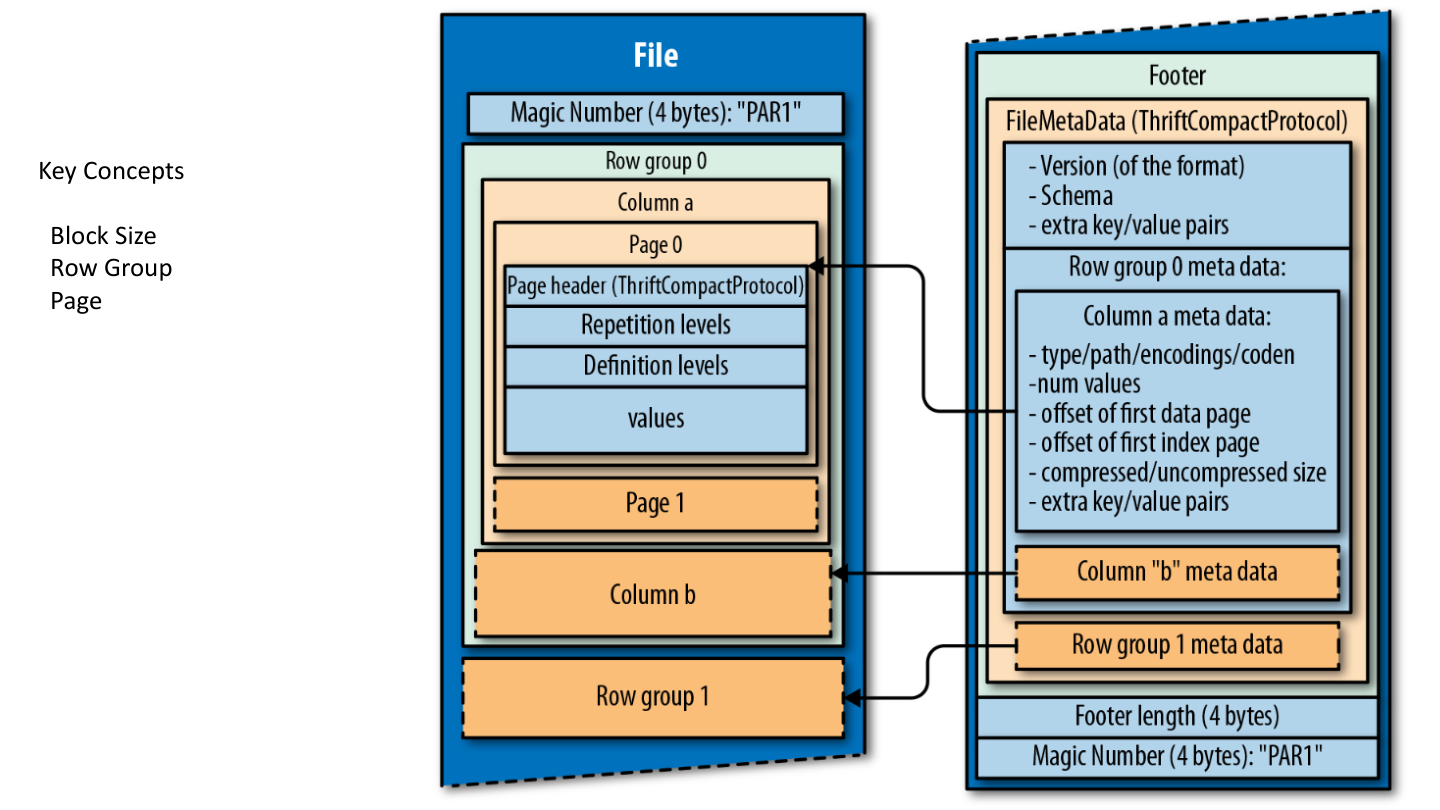


## Units of parallelization

- **MapReduce or distributed processing:** file or row group
- **I/O:** column chunk
- **Encoding and compression:** page

This hierarchy lets engines divide work while reading only the relevant columns and row groups.


## Compression and nested data

- Parquet supports compression at the page level.
- Column chunks are split into pages, which bounds encoding and decoding work.
- Nested columns are represented using repetition and definition levels, based on the Dremel model.
- A small set of physical types is combined with logical annotations to represent richer data types.


## Glossary

- **Block:** A storage-system block; Parquet is designed to work efficiently with systems such as HDFS.
- **File:** A Parquet file that contains file metadata and usually the data itself.
- **Row group:** A logical horizontal partition containing one column chunk for every column.
- **Column chunk:** Contiguous data for one column within a row group.
- **Page:** An indivisible unit for encoding and compression within a column chunk.

**Hierarchy:** File → row group → column chunk → page


## File format

```text
PAR1
Row group 1: column chunk 1 ... column chunk N
Row group 2: column chunk 1 ... column chunk N
...
Row group M: column chunk 1 ... column chunk N
File metadata
File-metadata length (4 bytes)
PAR1
```

- A table with **N columns** and **M row groups** has up to `N × M` column chunks.
- Footer metadata records the location and details of each column chunk.
- Writers place metadata after the data to support single-pass writing.
- Readers inspect the footer first, then read only the required column chunks.


## Metadata

Parquet uses three main kinds of metadata:

1. **File metadata** — schema, row groups, and file-level information
2. **Column-chunk metadata** — type, encodings, statistics, sizes, and offsets
3. **Page-header metadata** — page type, sizes, encoding, and related details

Metadata structures are defined with Apache Thrift and serialized using the Thrift Compact Protocol.


## Physical types

- `BOOLEAN` — Boolean values
- `INT32` — 32-bit signed integers
- `INT64` — 64-bit signed integers
- `INT96` — legacy 96-bit values; avoid for new schemas when possible
- `FLOAT` — IEEE 754 single-precision values
- `DOUBLE` — IEEE 754 double-precision values
- `BYTE_ARRAY` — variable-length byte sequences
- `FIXED_LEN_BYTE_ARRAY` — fixed-length byte sequences

Smaller integers can use an `INT32` physical type with an appropriate logical annotation and encoding.


## Logical types

Logical types add meaning to physical storage types.

- Strings use binary storage with a `STRING` annotation.
- Other examples include `ENUM`, `UUID`, signed and unsigned integers, `DECIMAL`, `DATE`, `TIME`, and `TIMESTAMP`.
- Logical annotations allow applications to interpret stored values consistently without expanding the physical type system.

See the [Parquet logical-type specification](https://github.com/apache/parquet-format/blob/master/LogicalTypes.md).


## Key takeaways

- Parquet is optimized for analytical workloads and selective column reads.
- Row groups provide coarse-grained parallelism and data skipping.
- Column chunks isolate columns; pages provide encoding and compression boundaries.
- Footer metadata enables readers to locate and skip data efficiently.

### References

- [Apache Parquet documentation](https://parquet.apache.org/docs/)
- [Apache Parquet format specification](https://github.com/apache/parquet-format)
